# Results Analysis

Regenerates every figure from the saved CSVs in `notebooks/results/` (no model inference). Figures are saved to `notebooks/new_results/`.

`STT_Comparison-wPrompt wBERT.ipynb` produced the CSVs but used the earlier plotting code, so its embedded figures are outdated.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent)) #repo root, so `src` is importable from notebooks/

from src.aggregate import build_summary_report
from src.config import LATENCY_RESULTS_FILENAME, COST_EFFICIENCY_FILENAME, ACCENT_RESULTS_FILENAME, BERT_SCORES_FILENAME
from src.io_utils import load_results
from src.plots import (save_figure, plot_accuracy_latency, plot_precision_recall_f1, plot_speed_overview, plot_wer_comparison, plot_accuracy_overview,
                       plot_semantic_overview, plot_prompt_shift, plot_radar_profiles, plot_summary_table)

In [2]:
df_latency = load_results(LATENCY_RESULTS_FILENAME)
df_cost = load_results(COST_EFFICIENCY_FILENAME)
df_accent = load_results(ACCENT_RESULTS_FILENAME)
df_bert = load_results(BERT_SCORES_FILENAME)

## Part 1: Latency and cost

On the basic metrics, all the models have a respectable score in the 80-90% range. Low precision means the model adds words (hallucination), and low recall means it drops words.

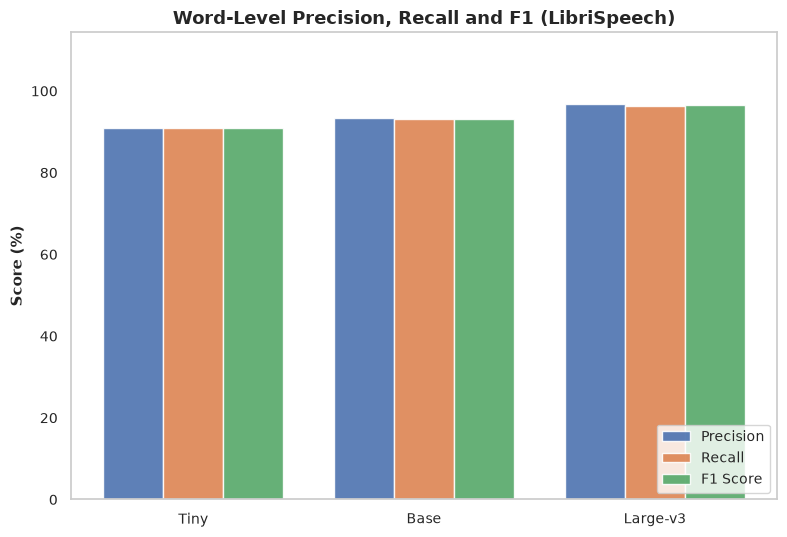

In [3]:
fig = plot_precision_recall_f1(df_latency)
save_figure(fig, 'precision_recall_f1.png')
plt.show()

Smaller models have higher WER and lower latency, but notice that Tiny performs quite similarly to Base. However, our clips range between 5 to 16 seconds. Therefore, this may be a consequence of the length of our clips, where longer clips may show the Base model significantly outperforming the Tiny model.

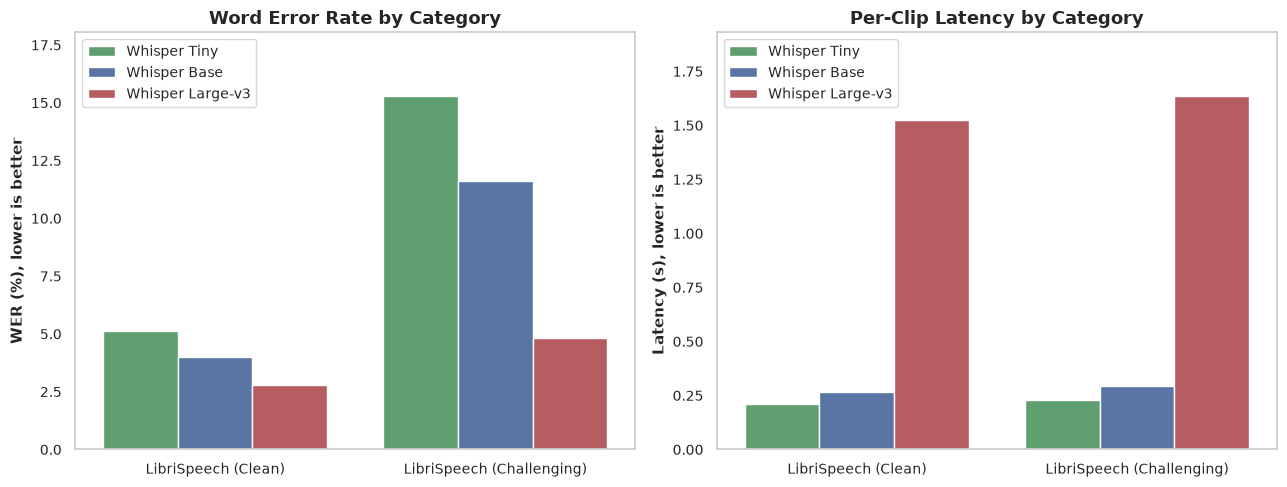

In [4]:
fig = plot_accuracy_latency(df_latency)
save_figure(fig, 'part1_accuracy_latency.png')
plt.show()

In terms of speed and cost:
- Tiny and Base are fast and cheap, with median latency around 200-250 ms, real-time factors of roughly 0.04-0.05, tail latencies (p99) under about 700 ms, and compute costs of about $20-25 per 1,000 audio hours.
- Large-v3 is far slower and costlier: median latency is about 1,450 ms, p99 approaches 3,500 ms, RTF is about 0.30 (6-7x higher), and cost is around $285 per 1,000 audio hours, more than 10x the smaller models.
- What you get for that price is accuracy, since mean WER drops from about 10% in the Tiny model to under 4% (Large-v3). 

Base looks like the sweet spot for latency-sensitive or budget-constrained use, since it cuts WER by about 2.5 points over Tiny at almost no extra cost, while Large-v3 makes sense when accuracy matters most and the added latency and expense are acceptable.
Note that all three models are well below real time (RTF under 1), so even Large-v3 can keep up with live audio in sequential processing, though its wider tail latency could matter for interactive applications.

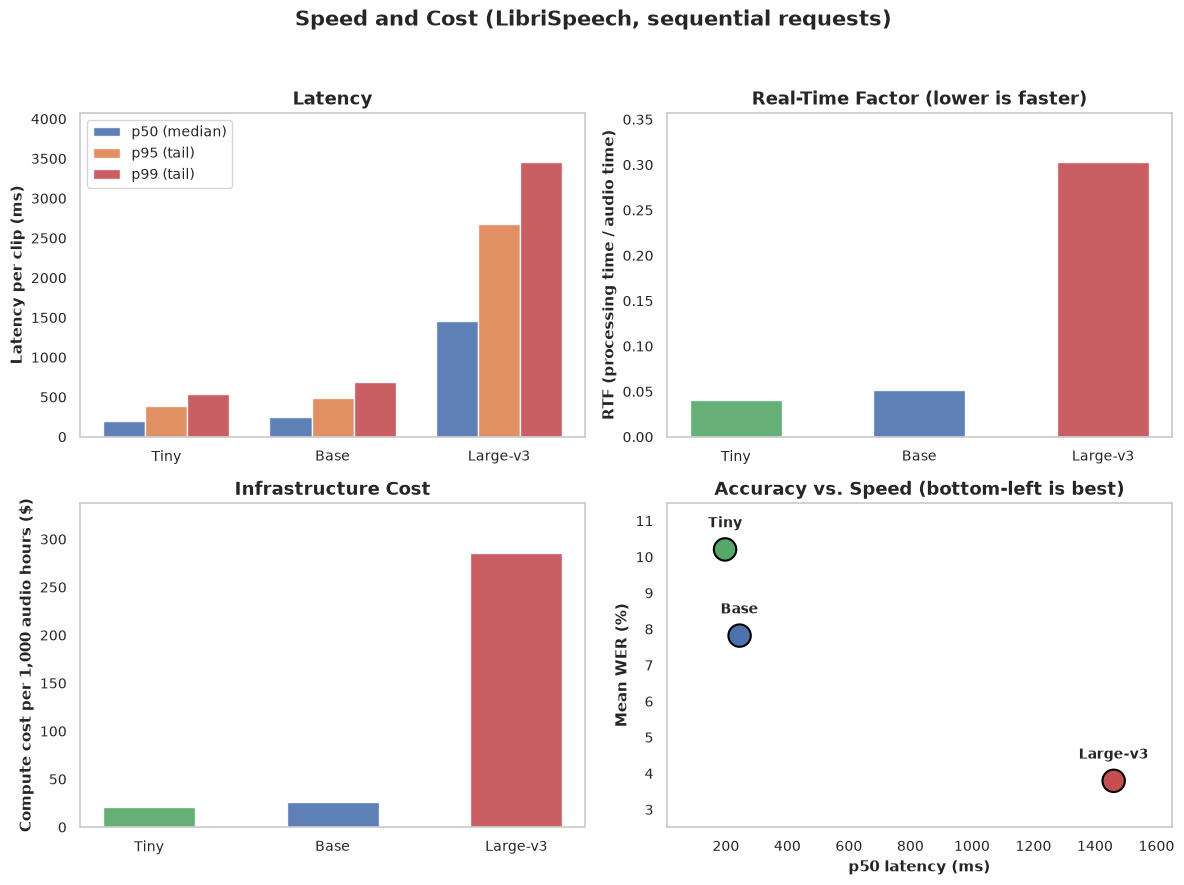

In [5]:
fig = plot_speed_overview(df_latency, df_cost)
save_figure(fig, 'speed_overview.png')
plt.show()

## Part 2: Accent robustness

We introduced some known-to-be challenging accents like Singaporean and Indian, while also including the classic British. The Large model performed the best, as expected, but it did fail some British samples. 

When a very simple prompt like hinting the type of accent was given, the models' performance degraded significantly. We suspect that the prompt actually bloated the context window and led to the model conditioning on the prompt instead of the audio sound. Naturally, the conclusion here is to exclude prompts for the smaller models.

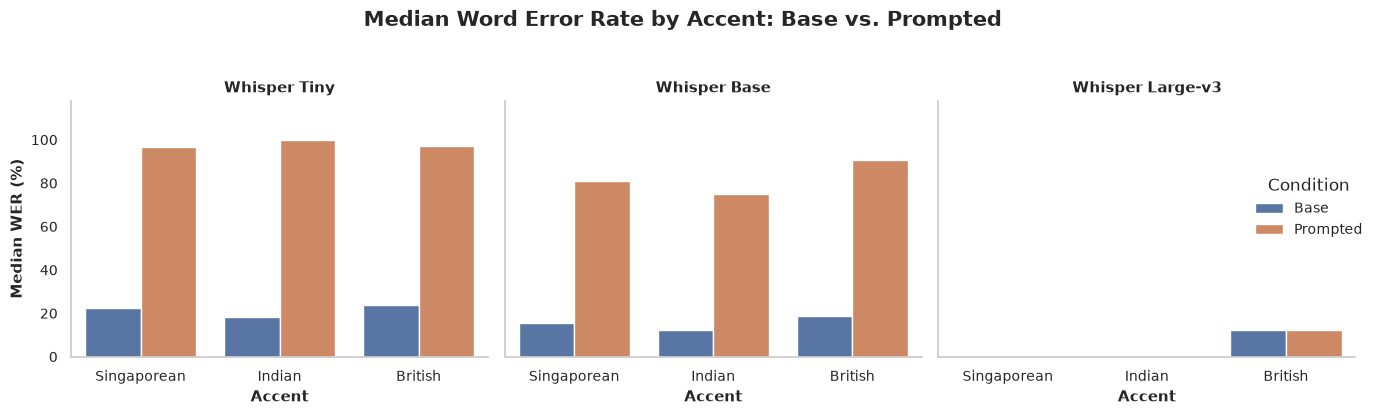

In [6]:
fig = plot_wer_comparison(df_accent)
save_figure(fig, 'wer_by_accent.png')
plt.show()

Based on the error types, we found that the smaller models have a habit of inserting words. Here, you can treat insertions as False Positives and deletion as False Negatives. 

Therefore, if the focus is on capturing everything that was said, then insertions are alright. However, if the objective is just being able to read what was said like captions, then deletions are fine as humans do not need the full sentence to understand the context. Lastly, if you are using this to make a decision on what was said, then both would be important.

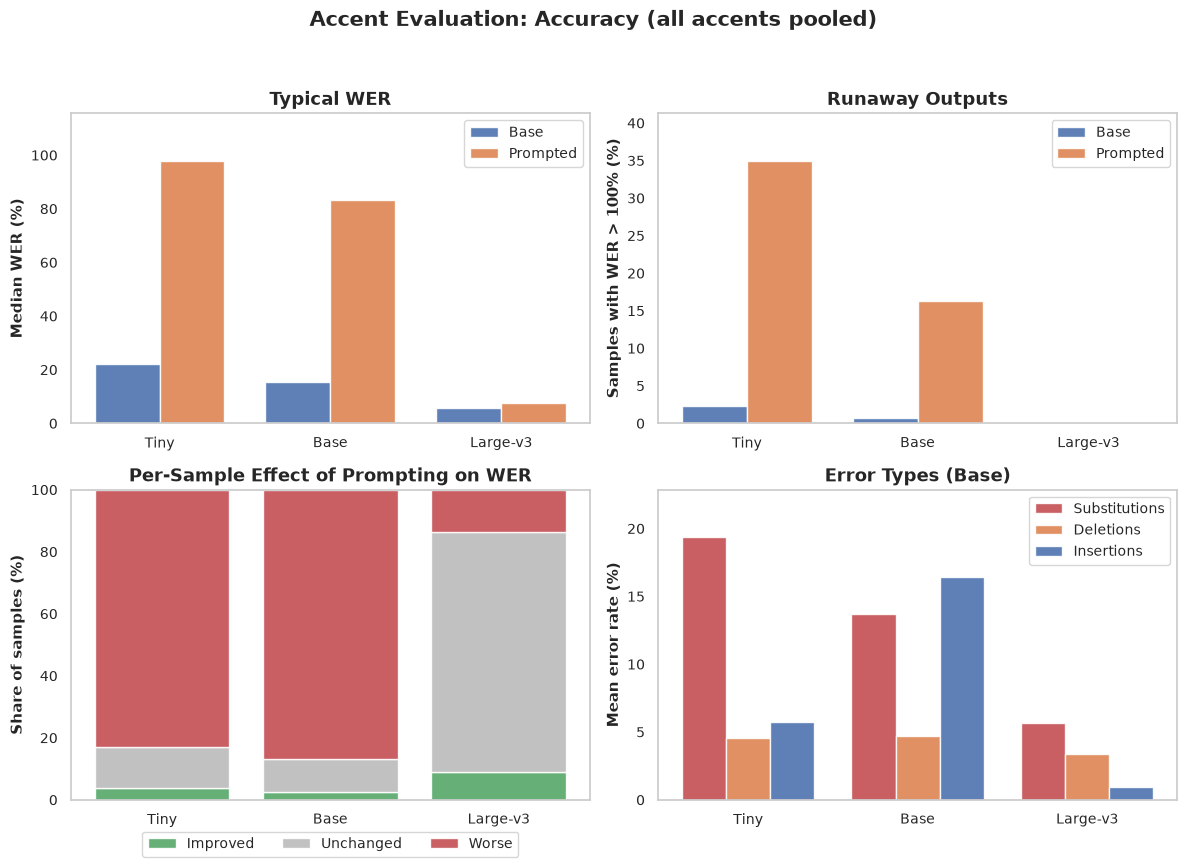

In [7]:
fig = plot_accuracy_overview(df_accent)
save_figure(fig, 'accuracy_overview.png')
plt.show()

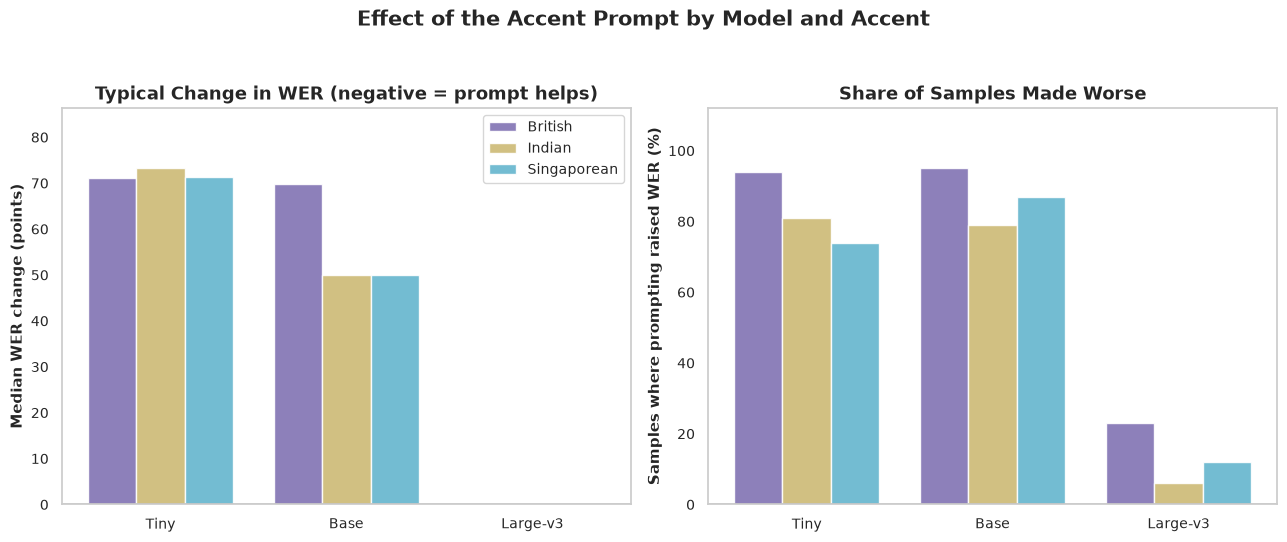

In [8]:
fig = plot_prompt_shift(df_accent)
save_figure(fig, 'prompt_shift.png')
plt.show()

## Part 3: Semantic evaluation

Next, we consider the semantic similarity of each transcript to its reference, measured by BERT-F1. Naturally, the results are similar to WER. However, note that all models perform reasonably well and actually capture the main gist of what was said.

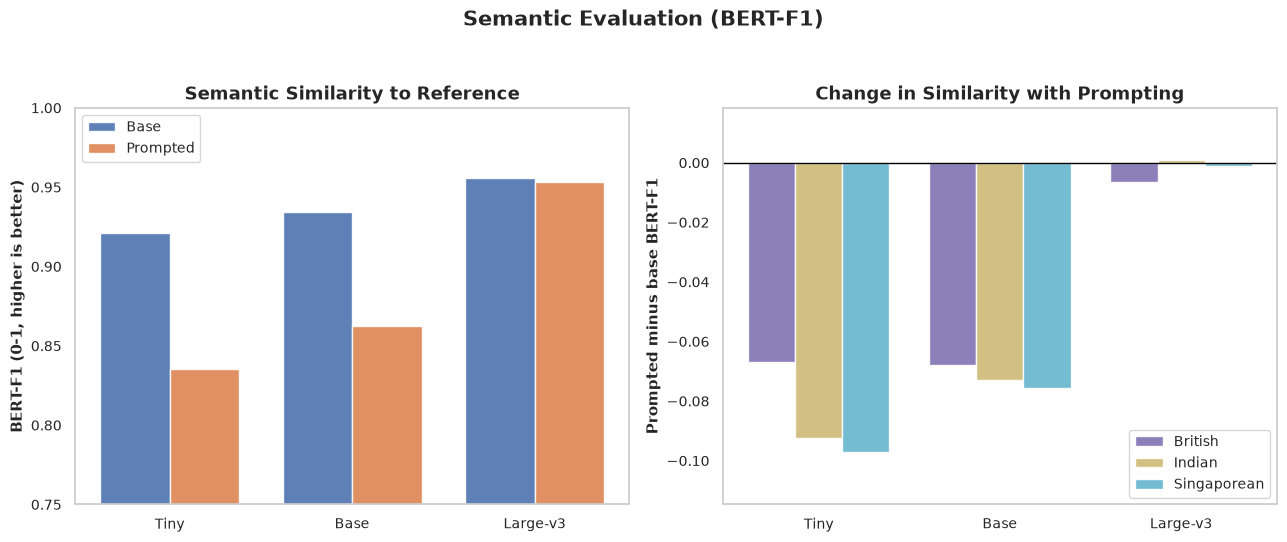

In [9]:
fig = plot_semantic_overview(df_bert)
save_figure(fig, 'semantic_overview.png')
plt.show()

## Part 4: Comparison

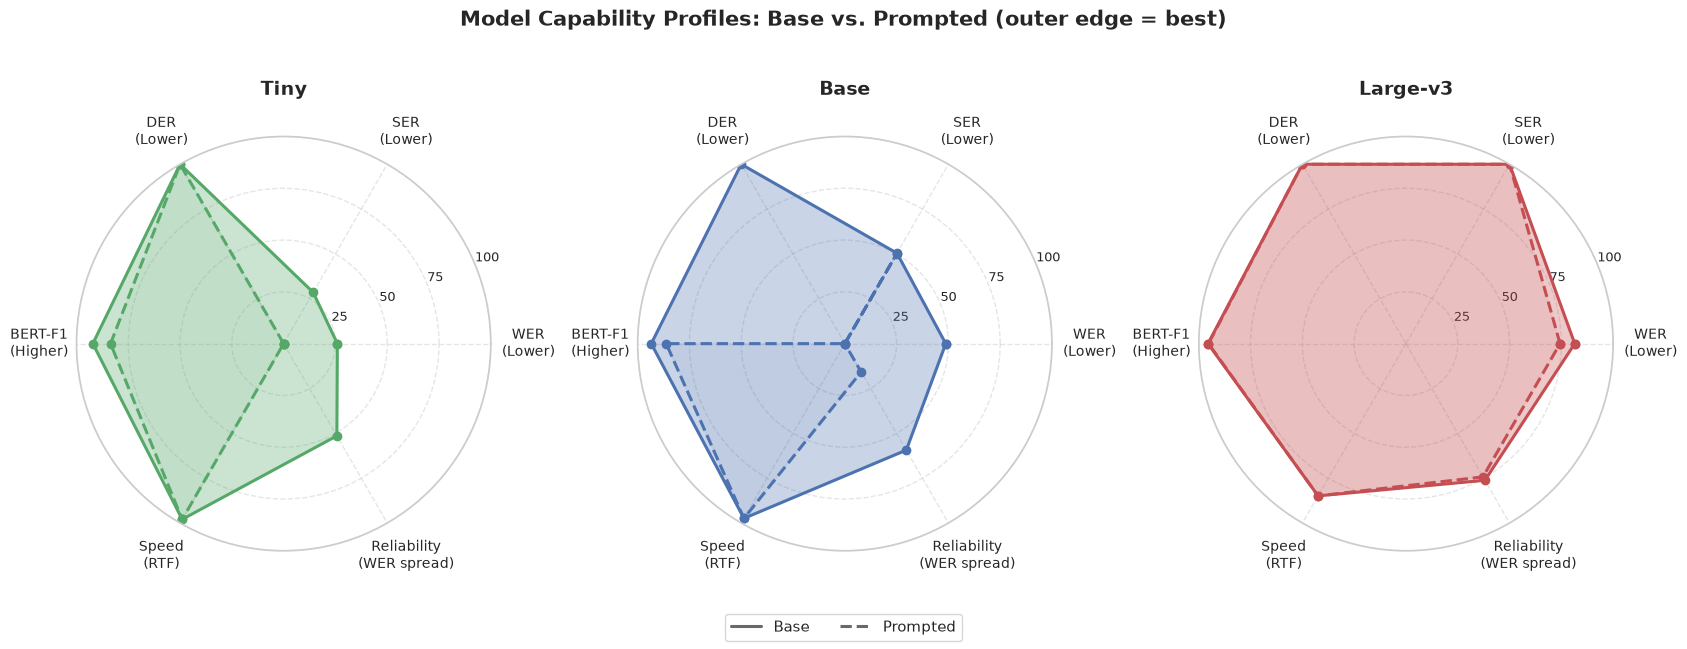

In [10]:
fig = plot_radar_profiles(df_latency, df_accent, df_bert)
save_figure(fig, 'radar_profiles.png')
plt.show()

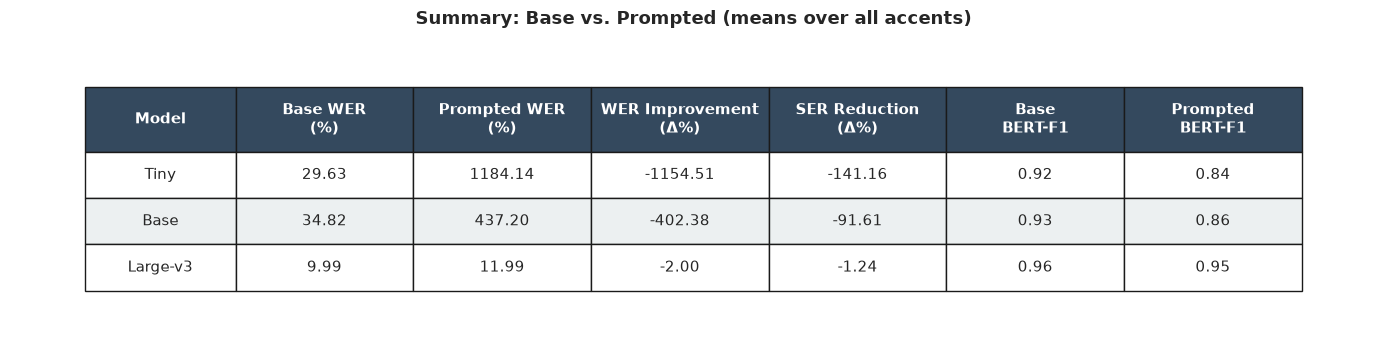

In [11]:
summary_report = build_summary_report(df_accent, df_bert)
fig = plot_summary_table(summary_report)
save_figure(fig, 'summary_table.png')
plt.show()

## Analysis: mistakes, prompting and recommendation

**How mistakes are counted.** Each reference/hypothesis pair is normalised exactly as the WER metric does (lower-case, punctuation removed) and aligned word by word. Every edit is then given one rule-based label:

| Label | Rule |
|---|---|
| Numeral / abbreviation | a digit on either side, or *missus/mrs*-style pairs |
| Function-word swap | both words are common function words (*and/in*, *the/a*) |
| Near-spelling variant | similarity of the two words >= 0.7 (*knight/night*, *carcases/carcasses*) |
| Different word | any other substitution |
| Dropped / Extra word | deletion / insertion |

In [12]:
import pandas as pd
from transformers import WhisperProcessor

from src.analysis import build_edit_table, edit_category_counts, top_confusions, output_type_counts, classify_output, pick_examples
from src.config import ACCENT_PROMPTS, MODEL_IDS, MODEL_ORDER
from src.plots import plot_edit_categories, plot_output_types

pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 200)
df_ls = df_latency.rename(columns={"System": "Model"})

### 1. What mistakes do the three models make?

#### Part 1: LibriSpeech (read speech)

In [13]:
ls_wer = df_ls.groupby(["Model", "Category"])["WER (%)"].agg(["mean", "median"]).round(1).unstack("Model")[[("mean", m) for m in MODEL_ORDER] + [("median", m) for m in MODEL_ORDER]]
ls_wer

mean                                     median                              
Model                     Whisper Tiny Whisper Base Whisper Large-v3 Whisper Tiny Whisper Base Whisper Large-v3
Category                                                                                                       
LibriSpeech (Challenging)         15.3         11.6              4.8         12.9          8.4              0.0
LibriSpeech (Clean)                5.1          4.0              2.8          0.0          0.0              0.0

In [14]:
ls_edits = build_edit_table(df_ls, "Model", "Reference", "Hypothesis")
ls_counts = edit_category_counts(ls_edits, MODEL_ORDER)
ls_counts["Total edits"] = ls_counts.sum(axis=1)
ls_counts

Category,Numeral / abbreviation,Function-word swap,Near-spelling variant,Different word,Dropped word,Extra word,Total edits
Model,,,,,,,
Whisper Tiny,20,38,99,117,41,40,355
Whisper Base,11,21,67,99,34,31,263
Whisper Large-v3,11,8,36,36,25,4,120


In [15]:
ls_confusions = pd.concat({model: top_confusions(ls_edits, model, 6) for model in MODEL_ORDER}, names=["Model"]).reset_index(level=0)
ls_confusions

,Model,Kind,Reference word,Hypothesis word,Count
0,Whisper Tiny,substitute,and,in,6
1,Whisper Tiny,substitute,in,and,4
2,Whisper Tiny,substitute,knight,night,4
3,Whisper Tiny,substitute,thee,the,4
4,Whisper Tiny,insert,,a,3
5,Whisper Tiny,delete,a,,3
0,Whisper Base,substitute,and,in,6
1,Whisper Base,substitute,geraint,durant,4
2,Whisper Base,insert,,the,3
3,Whisper Base,insert,,up,3


Note that the errors stem from quirky sounding words and sometimes simply stylistic choice like three instead of 3. However, also note that the models tend to confuse "which he" and "xx she".

In [16]:
ls_examples = pd.concat([pick_examples(df_ls, model, "WER (%)", 3) for model in MODEL_ORDER])
ls_examples[["Model", "Clip ID", "WER (%)", "Reference", "Hypothesis"]]

,Model,Clip ID,WER (%),Reference,Hypothesis
198,Whisper Tiny,ls_other_99,62.50,AND EVERY ONE ASKED THAT WHICH HE DESIRED,and everyone asks that what she desired.
181,Whisper Tiny,ls_other_82,57.14,TO GUENEVER AND HER HANDMAIDENS SAID HE,"To quiver in her hand, maiden said he."
136,Whisper Tiny,ls_other_37,50.00,ABAFT THE FORE HATCH IS THE ICE HOUSE,About the 4 hatch is the A-SOS.
381,Whisper Base,ls_other_82,85.71,TO GUENEVER AND HER HANDMAIDENS SAID HE,to Gwent over in her hand made and said he.
398,Whisper Base,ls_other_99,62.50,AND EVERY ONE ASKED THAT WHICH HE DESIRED,and everyone asks that what she desired.
306,Whisper Base,ls_other_7,50.00,THEN GERAINT WENT TO SEE ERBIN,Then your aunt went to see urban.
454,Whisper Large-v3,ls_clean_55,44.44,THREE O'CLOCK CAME FOUR FIVE SIX AND NO LETTER,"3 o'clock came, 4, 5, 6, and no letter."
536,Whisper Large-v3,ls_other_37,37.50,ABAFT THE FORE HATCH IS THE ICE HOUSE,Above the forehatch is the ice house.
506,Whisper Large-v3,ls_other_7,33.33,THEN GERAINT WENT TO SEE ERBIN,Then Duraint went to see Urban.


**Reading the Part 1 tables**

- **Size changes how many mistakes, not which kind.** Tiny makes 355 word edits, Base 263 and Large-v3 120 (34% of Tiny's). The mix barely moves: substitutions are 77% / 75% / 76% of edits, and near-spelling plus different-word errors are 61% / 63% / 60%.
- **Hard audio hurts small models most.** Going from the clean to the challenging split multiplies mean WER by 3.0x for Tiny (5.1 to 15.3) and 2.9x for Base (4.0 to 11.6), but only 1.7x for Large-v3 (2.8 to 4.8). Median WER is 0 on the clean split for every model, so most clean clips are transcribed perfectly.
- **What the errors look like.**
    - The small models confuse short function words and sound-alikes (*and/in* 6x for both, *knight/night*, *thee/the*) and mangle rare names (*Geraint* becomes *Durant* in Base, *Guenever* becomes *To quiver* in Tiny). 
    - Large-v3 mostly gets the sound right but the spelling or format differently: *Guenever* / *Guinevere*, *carcases* / *carcasses*, *forehatch*, and *"3 o'clock came, 4, 5, 6"* against the reference *"THREE O'CLOCK CAME FOUR FIVE SIX"*.
- **Failure is concentrated in a few clips.** The same few `ls_other` clips (`ls_other_99`, `_82`, `_37`, `_7`) recur in the worst-three lists of different models: rare names and archaic wording, not general noise.

#### Part 2: accented speech, no prompt

Seven Tiny and two Base transcripts have WER above 100% even without a prompt, and one of them (a 7-word reference) reaches 4,229% because the model looped. These would dominate the edit counts, so the edit analysis below leaves them out and reports them separately.

In [17]:
df_typical = df_accent[df_accent["Base WER (%)"] <= 100]
n_excluded = df_accent.groupby("Model")["Base WER (%)"].apply(lambda wer: int((wer > 100).sum())).reindex(MODEL_ORDER)
mean_all = df_accent.groupby("Model")["Base WER (%)"].mean().reindex(MODEL_ORDER).round(1)
mean_typical = df_typical.groupby("Model")["Base WER (%)"].mean().reindex(MODEL_ORDER).round(1)
pd.DataFrame({"Base WER>100% samples": n_excluded, "Mean base WER (all)": mean_all, "Mean base WER (excl. those)": mean_typical})

,Base WER>100% samples,Mean base WER (all),Mean base WER (excl. those)
Model,,,
Whisper Tiny,7,29.6,26.2
Whisper Base,2,34.8,20.4
Whisper Large-v3,0,10.0,10.0


In [18]:
accent_wer = df_accent.groupby(["Accent", "Model"])["Base WER (%)"].agg(["mean", "median"]).round(1).unstack("Model")
accent_wer

mean                                     median                              
Model       Whisper Base Whisper Large-v3 Whisper Tiny Whisper Base Whisper Large-v3 Whisper Tiny
Accent                                                                                           
British             64.0             13.2         31.3         18.9             12.1         23.8
Indian              20.3              8.5         25.3         12.5              0.0         18.2
Singaporean         20.2              8.3         32.3         15.4              0.0         22.2

In [19]:
accent_edits = build_edit_table(df_typical, "Model", "Reference", "Base Hypothesis")
accent_counts = edit_category_counts(accent_edits, MODEL_ORDER)
accent_counts["Total edits"] = accent_counts.sum(axis=1)
accent_counts

Category,Numeral / abbreviation,Function-word swap,Near-spelling variant,Different word,Dropped word,Extra word,Total edits
Model,,,,,,,
Whisper Tiny,12,88,154,511,350,125,1240
Whisper Base,11,61,139,325,362,109,1007
Whisper Large-v3,13,23,84,113,298,44,575


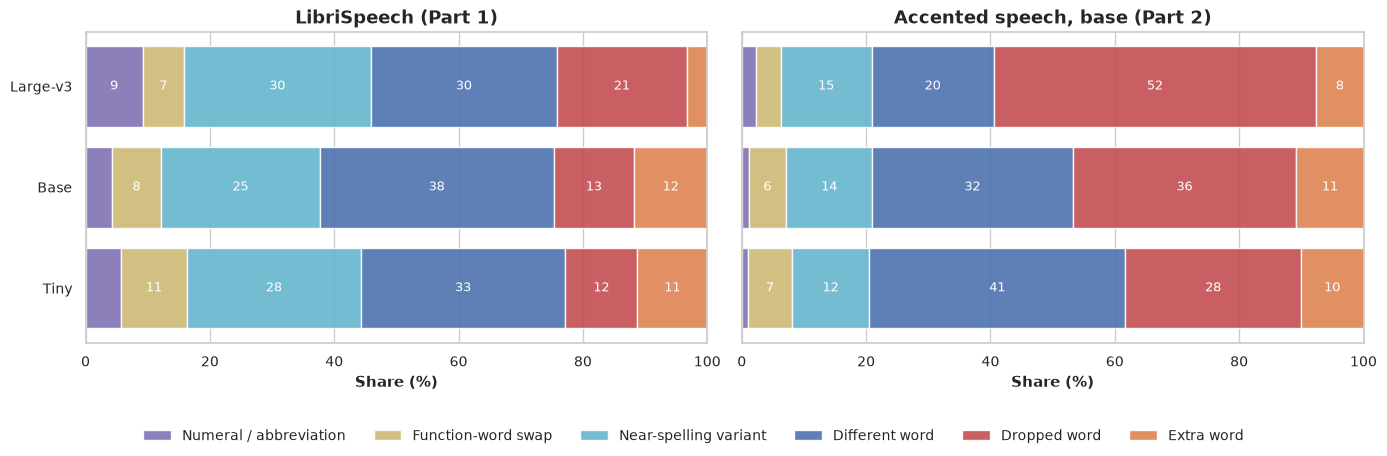

In [20]:
fig = plot_edit_categories(ls_counts.drop(columns="Total edits"), accent_counts.drop(columns="Total edits"))
save_figure(fig, "edit_categories.png")
plt.show()

In [21]:
accent_confusions = pd.concat({model: top_confusions(accent_edits, model, 6) for model in MODEL_ORDER}, names=["Model"]).reset_index(level=0)
accent_confusions

,Model,Kind,Reference word,Hypothesis word,Count
0,Whisper Tiny,delete,i,,21
1,Whisper Tiny,delete,like,,19
2,Whisper Tiny,delete,a,,11
3,Whisper Tiny,delete,the,,11
4,Whisper Tiny,delete,um,,9
5,Whisper Tiny,delete,but,,8
0,Whisper Base,delete,i,,21
1,Whisper Base,delete,like,,15
2,Whisper Base,delete,the,,11
3,Whisper Base,delete,um,,11


In [22]:
drops = {}
for (model, accent), group in df_typical.groupby(["Model", "Accent"]):
    edits = build_edit_table(group, "Model", "Reference", "Base Hypothesis")
    drops[(model, accent)] = {"Total edits": len(edits), "Dropped words": int((edits["Category"] == "Dropped word").sum())}
drops_table = pd.DataFrame.from_dict(drops, orient="index", dtype="int64").unstack(0).reindex(columns=pd.MultiIndex.from_product([["Total edits", "Dropped words"], MODEL_ORDER]))
drops_table

Total edits                               Dropped words                              
            Whisper Tiny Whisper Base Whisper Large-v3  Whisper Tiny Whisper Base Whisper Large-v3
British              770          635              430           316          327              287
Indian               195          167               63            10           21                2
Singaporean          275          205               82            24           14                9

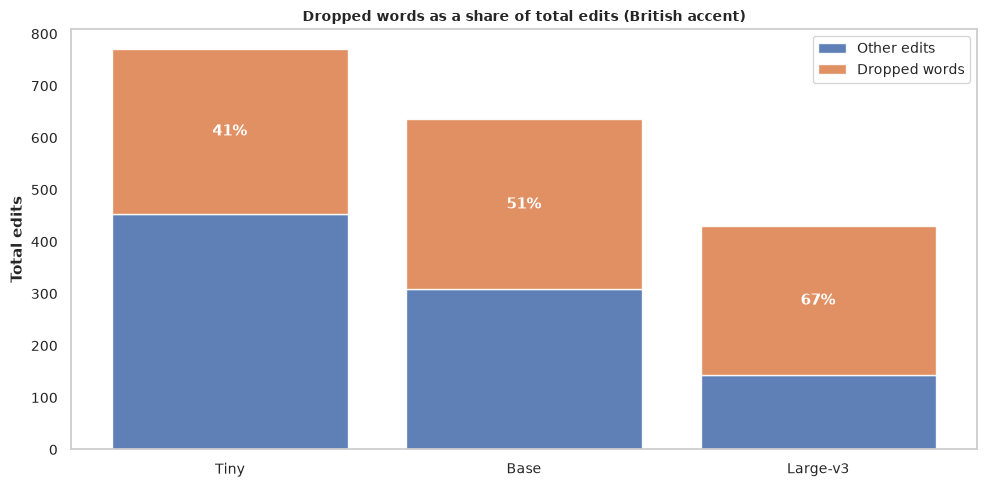

In [68]:
british = drops_table.loc["British"]
totals = british["Total edits"].reindex(MODEL_ORDER)
dropped = british["Dropped words"].reindex(MODEL_ORDER)
other = totals - dropped
dropped_share = dropped / totals * 100

models = [model.replace("Whisper ", "") for model in MODEL_ORDER]
OTHER_COLOR = "#4C72B0"
DROPPED_COLOR = "#DD8452"

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(models, other, label="Other edits", color=OTHER_COLOR, alpha=0.9)
ax.bar(models, dropped, bottom=other, label="Dropped words", color=DROPPED_COLOR, alpha=0.9)

for model_idx, model in enumerate(models):
    ax.text(model_idx, other.iloc[model_idx] + dropped.iloc[model_idx] / 2, f"{dropped_share.iloc[model_idx]:.0f}%", ha="center", va="center", color="white", fontweight="bold")

ax.set_ylabel("Total edits")
ax.set_title("Dropped words as a share of total edits (British accent)", fontdict={'size':10})
ax.legend()
ax.grid(False)
save_figure(fig, 'dropped_words_british_accent')
plt.tight_layout()
plt.show()

In [24]:
hard_base = pd.concat([pick_examples(df_typical, model, "Base WER (%)", 2) for model in MODEL_ORDER])
hard_base[["Model", "Accent", "Sample Index", "Base WER (%)", "Reference", "Base Hypothesis"]]

,Model,Accent,Sample Index,Base WER (%),Reference,Base Hypothesis
131,Whisper Tiny,Indian,32,100.0,His vanity is colossal.,is BANETY'S COOLO SON
124,Whisper Tiny,Indian,25,100.0,In the post-orange-juice era?,In the post or in this era
370,Whisper Base,Singaporean,71,100.0,Cancelled projects are in italics.,Cancel project signing eye tactics.
431,Whisper Base,Indian,32,100.0,His vanity is colossal.,"It's banities, kula san."
735,Whisper Large-v3,Indian,36,100.0,I'm an entry-level clerk.,I am an entry level clerk
731,Whisper Large-v3,Indian,32,75.0,His vanity is colossal.,It's Vanity's Colossal


In [25]:
runaway = df_accent.sort_values("Base WER (%)", ascending=False).groupby("Model").head(5)
runaway[["Model", "Accent", "Sample Index", "Base WER (%)", "Reference"]].assign(**{"Base Hypothesis": runaway["Base Hypothesis"].str[:110]})

,Model,Accent,Sample Index,Base WER (%),Reference,Base Hypothesis
532,Whisper Base,British,33,4228.57,ALMOST ALMOST CERTAINLY WENT A TAD INSANE,"my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my"
228,Whisper Tiny,British,29,398.08,YEAH NO IT'S GREAT IT STARTED LIKE MAYBE LIKE FIVE OR SIX YEARS AGO MY SISTER WAS LIKE ''OH LET'S WATCH DIE HARD'' AND THEN I ...,"Yeah, no, it's great. So I did like maybe like five or six years ago. My sister was like, Oh, that's which tim"
76,Whisper Tiny,Singaporean,77,200.00,Criminal mischief is usually a misdemeanor.,I'm going to make a mistake if you're going to be a millionaire.
120,Whisper Tiny,Indian,21,133.33,Stop harassing me!,"Stop, how do I say me?"
45,Whisper Tiny,Singaporean,46,128.57,Privatisations have always been controversial in Ireland.,"For our organizations that always in country of usher and Ireland,"
435,Whisper Base,Indian,36,125.00,I'm an entry-level clerk.,I am an entry level click.
135,Whisper Tiny,Indian,36,125.00,I'm an entry-level clerk.,I am an intray level click
431,Whisper Base,Indian,32,100.00,His vanity is colossal.,"It's banities, kula san."
370,Whisper Base,Singaporean,71,100.00,Cancelled projects are in italics.,Cancel project signing eye tactics.
735,Whisper Large-v3,Indian,36,100.00,I'm an entry-level clerk.,I am an entry level clerk


In [66]:
conds = (df_typical['Model'] == 'Whisper Large-v3') & (df_typical['Accent'] == 'British')
word_cond = df_typical['Reference'].str.contains(
    r'\b(?:like|um)\b', case=False, na=False
) # I and You are used often, will be hard to analyze

df_typical.loc[conds & word_cond].sort_values(by='Base WER (%)', ascending=False).head(5)

,Model,Accent,Sample Index,Reference,Base Hypothesis,Prompted Hypothesis,Base WER (%),Prompted WER (%),Base SER (%),Prompted SER (%),SER Reduction (Δ%),Base DER (%),Prompted DER (%),Base IER (%),Prompted IER (%)
851,Whisper Large-v3,British,52,YOU KNOW I'M NOT GON I USED TO LOVE UM YOU KNOW THE THE JIM CARREY MOVIE THE MASK,"I used to love the Jim Carrey movie, The Mask.","I used to love the Jim Carrey movie, The Mask.",47.37,47.37,0.00,0.00,0.00,47.37,47.37,0.00,0.00
830,Whisper Large-v3,British,31,IT'S LIKE YOU WATCH HOME ALONE OR THE THE SCROOGE MCDUCK ONE OR WHATEVER THAT'S CALLED OR DIE HARD BUT I REMEMBER A FEW YEARS ...,"It's like you watch Home Alone or the Scrooge McDuck one, whatever that's called, or Die Hard. But I remember a few years ago,...","It's like you watch Home Alone or the Scrooge McDuck one, whatever that's called, or Die Hard. But I remember a few years ago,...",46.45,44.52,8.39,6.45,23.08,37.42,37.42,0.65,0.65
856,Whisper Large-v3,British,57,YEAH I GUESS SO THEY'RE LIKE <OVERLAP>,"Yeah, I guess so.","Yeah, I guess so.",42.86,42.86,0.00,0.00,0.00,42.86,42.86,0.00,0.00
881,Whisper Large-v3,British,82,LIKE A DID YOU LIKE PICKLE IT OR IS IT PRESERVED,Did you pickle it or is it preserved in,Did you pickle it or is it preserved in,36.36,36.36,0.00,0.00,0.00,27.27,27.27,9.09,9.09
872,Whisper Large-v3,British,73,JUST LIKE ON ITS OWN AND STUFF ON BREAD AND THINGS THAT WAS VERY VERY NICE AND I LIKED UM I LIKED COLIN THE CATERPILLAR CAKE A...,"It just went on its own and stuff, on bread and things. That was very, very nice. And I liked... I liked calling the cast for ...","It's like on its own and stuff, on bread and things. That was very, very nice. And I liked, I like calling the cast for the ca...",34.38,34.38,12.50,15.62,-25.00,12.50,12.50,9.38,6.25


**Reading the Part 2 tables and figure**

- **Substitutions shrink with size; dropped words do not.** Excluding the runaways, substitutions are 765 (Tiny), 536 (Base) and 233 (Large-v3) edits, but dropped words are 350, 362 and 298. For Large-v3 that makes deletions 52% of its edits.
- **The dropped words are a dataset effect.** The most common dropped words are the same for all three models: *i*, *like*, *um*, *you*. In the dropped-words table, most come from the British accent. The models write clean text, the reference keeps the raw form, hence it is not a problem unless the goal is to write as is.
- **Accent-specific mistakes are on rare words.** On the short read sentences, the hardest cases are the same for every model: *"His vanity is colossal."* is heard as *"is BANETY'S COOLO SON"* (Tiny), *"It's banities, kula san"* (Base) and *"It's Vanity's Colossal"* (Large-v3, 75% WER). *"Cancelled projects are in italics."* becomes *"Cancel project signing eye tactics."* in Base.

### 2. Prompt vs no prompt

Each transcript is labelled by how it failed: *Exact*, *Minor errors* (WER <= 20%), *Heavy errors* (20-100%), *Truncated* (2 words or fewer for a longer reference), *Prompt echo* (the output repeats the prompt), *Repetition loop* (gzip compression ratio above 2.4, the same repetition heuristic Whisper itself uses) and *Runaway* (WER above 100% without a loop).

Prompting pushes the smaller models from ordinary transcription errors into catastrophic failures, while Large-v3 is almost unaffected. Without a prompt, Base and Tiny produce about 61% and 47% exact or minor-error transcripts and almost no degenerate outputs, but with a prompt this falls to roughly 13% for both.

The prompt had an adverse effect on our models as it likely bloated the context window of our models. Particularly, this is evident from the smaller Base and Tiny models where the errors mainly stem from Truncated and Repetition loop.

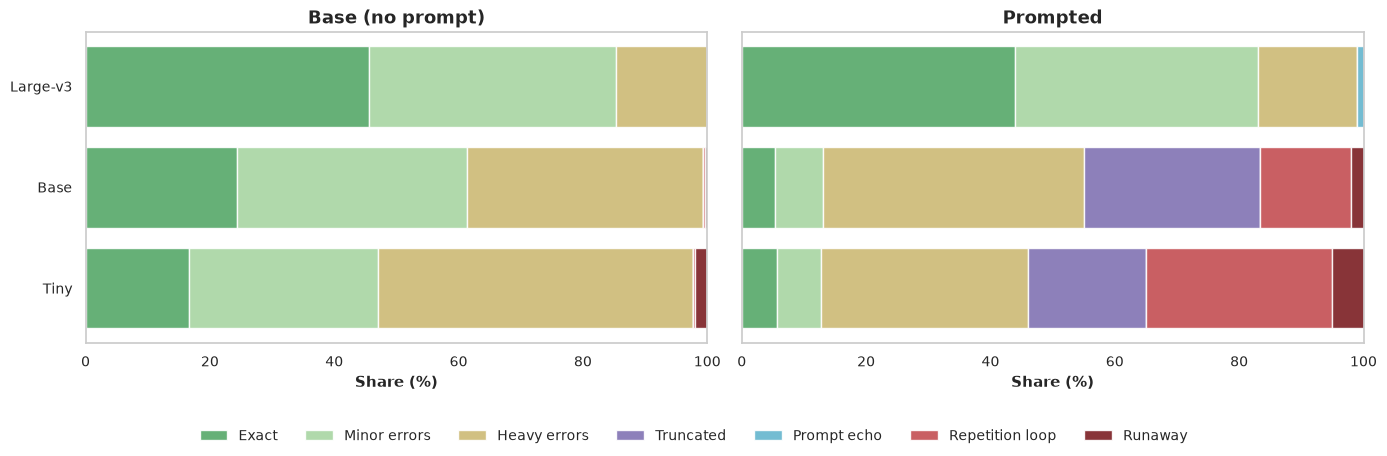

col_0                       Exact  Minor errors  Heavy errors  Truncated  Prompt echo  Repetition loop  Runaway
Condition Model                                                                                                
Base      Whisper Tiny       16.7          30.3          50.7        0.0          0.0              0.3      2.0
          Whisper Base       24.3          37.0          38.0        0.0          0.0              0.3      0.3
          Whisper Large-v3   45.7          39.7          14.7        0.0          0.0              0.0      0.0
Prompted  Whisper Tiny        5.7           7.0          33.3       19.0          0.0             30.0      5.0
          Whisper Base        5.3           7.7          42.0       28.3          0.0             14.7      2.0
          Whisper Large-v3   44.0          39.0          16.0        0.0          1.0              0.0      0.0

In [27]:
base_types = output_type_counts(df_accent, "Base Hypothesis", MODEL_ORDER)
prompted_types = output_type_counts(df_accent, "Prompted Hypothesis", MODEL_ORDER)
fig = plot_output_types(base_types, prompted_types)
save_figure(fig, "output_types.png")
plt.show()
pd.concat({"Base": base_types, "Prompted": prompted_types}, names=["Condition"]).round(1)

**What the prompt does to each model**

Note that Minor and Heavy errors refer to WER split by a threshold, we already discussed that above, so we will focus on the other 4 metrics.
- **Tiny and Base:** the share of the failed outputs in the following categories: truncated, loop, runaway or echo, goes from 2% to 54% for Tiny and from about 1% to 45% for Base.
- **Large-v3:** almost unchanged except for a 1%  increase in prompt echo.

In [ ]:
df_accent = df_accent.assign(**{
    "Prompted type": [classify_output(ref, hyp) for ref, hyp in zip(df_accent["Reference"], df_accent["Prompted Hypothesis"].fillna(""))]
})
tiny = df_accent[df_accent["Model"] == "Whisper Tiny"]
is_stock_phrase = tiny["Prompted Hypothesis"].str.startswith("The English translation")
pd.Series({
    "Tiny prompted outputs starting 'The English translation'": int(is_stock_phrase.sum()),
    "Median base WER on those same clips": float(tiny.loc[is_stock_phrase, "Base WER (%)"].median()),
    "Distinct prompted outputs of Tiny (of 300)": int(tiny["Prompted Hypothesis"].nunique())
}, dtype="float64")

Tiny prompted outputs starting 'The English translation'     69.0
Median base WER on those same clips                          25.0
Distinct prompted outputs of Tiny (of 300)                  190.0
dtype: float64

In [65]:
tiny.head(5)

,Model,Accent,Sample Index,Reference,Base Hypothesis,Prompted Hypothesis,Base WER (%),Prompted WER (%),Base SER (%),Prompted SER (%),SER Reduction (Δ%),Base DER (%),Prompted DER (%),Base IER (%),Prompted IER (%),Prompted type
0,Whisper Tiny,Singaporean,1,One could sense the struggle going on within.,One could sense the struggle going on within.,One could sense the struggle going on within.,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,Exact
1,Whisper Tiny,Singaporean,2,And a long time afterwards she brought her another supply.,"And a long time afterwards, she bought her a nade surprise.","And the long time afterwards, she bought her a native supply.",40.00,40.00,30.00,30.00,0.0,0.0,0.0,10.00,10.00,Heavy errors
2,Whisper Tiny,Singaporean,3,The project also would preserve greenspace throughout the city and create new parks.,The project also would preserve green space throughout the city and create new parks.,The project also would preserve pre-inspace throughout the city and create new parks.,15.38,7.69,7.69,7.69,0.0,0.0,0.0,7.69,0.00,Minor errors
3,Whisper Tiny,Singaporean,4,"However, Pakistan needed to apply to join.","However, Pakistan needed to apply to join.",However Pakistan needed to apply to join,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,Exact
4,Whisper Tiny,Singaporean,5,One wounded man was killed by a shell while the corporal was carrying him.,"One wounded man was killed by a shell, what a corporal was carrying him.",The English translation is a French translation is a French translation is a French translation is a French translation is a F...,14.29,3050.00,14.29,92.86,-550.0,0.0,0.0,0.00,2957.14,Repetition loop


In [30]:
broke = df_accent[(df_accent["Base WER (%)"] == 0) & (df_accent["Prompted WER (%)"] > 100)].groupby("Model").head(1)
broke = broke.assign(**{"Prompted Hypothesis": broke["Prompted Hypothesis"].str[:150] + "..."})
broke[["Model", "Accent", "Sample Index", "Reference", "Base Hypothesis", "Prompted Hypothesis"]]

,Model,Accent,Sample Index,Reference,Base Hypothesis,Prompted Hypothesis
32,Whisper Tiny,Singaporean,33,This is a simple consequence of the Lagrange form of the remainder.,This is a simple consequence of the Lagrange form of the remainder.,This is a simple consequence of the Lagrange form of the Lagrange form of the Lagrange form of the Lagrange form of the Lagran...
312,Whisper Base,Singaporean,13,It is the home of the football team of Harvard.,It is the home of the football team of Harvard.,It is the home of the home of the home of the home of the home of the home of the home of the home of the home of the home of ...


In [31]:
large = df_accent[df_accent["Model"] == "Whisper Large-v3"]
worse = large[large["Prompted WER (%)"] > large["Base WER (%)"] + 30] # Arbitrary values for a quick check
better = large[large["Prompted WER (%)"] < large["Base WER (%)"] - 15]
pd.concat({"Prompt hurt": worse.head(3), "Prompt helped": better.head(3)}, names=["Effect"])[["Accent", "Sample Index", "Reference", "Base Hypothesis", "Prompted Hypothesis"]]

Accent  Sample Index                                                                                          Reference  \
Effect                                                                                                                                            
Prompt hurt   717       Indian            18                                                                                  Lack of appetite!   
              836      British            37  PEOPLE PEOPLE WHEN THEY FIRST CAME OUT PEOPLE MOCKED THEM SO HARD AND NOW THEY'RE JUST EVERYWHERE   
              840      British            41                                     THE HELL OUT OF IT BUT THEN THEY NEVER ACTUALLY LIKE MADE THEM   
Prompt helped 608  Singaporean             9                                          Baldwin himself designed the two storey wood frame house.   
              657  Singaporean            58                                                            Normally such paper towels are two-ply.   
              690  Singaporean            91               One confirmed vector of the virus is the phlebotomine sand fly "Lutzomyia shannoni".   

                                                                                                  Base Hypothesis                                                             Prompted Hypothesis  
Effect                                                                                                                                                                                             
Prompt hurt   717                                                                                Like an Appetite                                                               Like an Appendage  
              836  people when they first came out people mocked them so hard and now they're just gonna remember                                                                    I was one of  
              840                                              the hell out of it. They never actually made them.         The following is an English transcription spoken with a British accent.  
Prompt helped 608                                           Bollig himself designed a do-sorry-would-frame house.                            Paul himself designed the Do-Sorry Wood frame house.  
              657                                                           Normally such paper towels are 2 ply.                                         Normally such paper towels are two-ply.  
              690                   One confirmed vector of the virus is the Phlebotomy sandfly Lutzomia shinoni.  One confirmed vector of the virus is the phlebotomy sand fly Lutzomia shinomi.

**Evidence from the outputs**

1. **Output unrelated to the audio.** 69 of Tiny's 300 prompted outputs start with *"The English translation"*, typically *"The English translation is a French translation is a French translation..."*, on clips whose base transcript was fine (median WER 25.0). The same sentence is produced for different speakers and sentences (for example for *"These are my top grades."* and *"Byron was born in California."*).
2. **Loops on clips that were exact without the prompt.** The `Lagrange form of the remainder` clip (Tiny) and the `home of the football team of Harvard` clip (Base) both had 0% WER unprompted and became *"...of the Lagrange form of the Lagrange form..."* and *"...the home of the home of the home..."* when prompted.

### 3. Recommendation

The table pulls every measure the notebook produced into one view (transposed so the models are columns).

In [33]:
cost = df_cost.set_index("System")
accent_median = df_accent.groupby("Model")[["Base WER (%)", "Prompted WER (%)"]].median()
prompted_failure = prompted_types[["Truncated", "Repetition loop", "Runaway", "Prompt echo"]].sum(axis=1)
recommendation = pd.DataFrame({
    "LibriSpeech WER (%)": df_ls.groupby("Model")["WER (%)"].mean(),
    "Accent median WER (%)": accent_median["Base WER (%)"],
    "Accent BERT-F1": df_bert.groupby("Model")["Base BERT-F1"].mean(),
    "p50 latency (ms)": cost["p50 Latency (ms)"],
    "p95 latency (ms)": cost["p95 Latency (ms)"],
    "RTF": cost["Mean RTF"],
    "Cost / 1,000 h ($)": cost["Cost / 1,000 Audio Hours ($)"],
    "Prompted: median WER (%)": accent_median["Prompted WER (%)"],
    "Prompted: failed outputs (%)": prompted_failure
}).reindex(MODEL_ORDER).round(3)
recommendation.T

,Whisper Tiny,Whisper Base,Whisper Large-v3
LibriSpeech WER (%),10.207,7.818,3.794
Accent median WER (%),22.220,15.380,5.560
Accent BERT-F1,0.921,0.934,0.956
p50 latency (ms),197.350,244.600,1460.850
p95 latency (ms),383.535,492.375,2677.620
RTF,0.041,0.052,0.303
"Cost / 1,000 h ($)",20.683,26.399,285.999
Prompted: median WER (%),97.985,83.330,7.690
Prompted: failed outputs (%),54.000,45.000,1.000


**Default: Whisper Large-v3, no accent prompt.**

| If the priority is... | Use | Why (from the table above) |
|---|---|---|
| Accuracy, accented or challenging audio, text read by people or fed to NLP | **Large-v3** | LibriSpeech WER 3.8% against 7.8% (Base) and 10.2% (Tiny); accent median WER 5.6 against 15.4 and 22.2; BERT-F1 0.956. It degrades least on hard audio (1.7x worse on the challenging split against about 3x for the small models). |
| Low cost or latency where a rough transcript is enough (search, tagging, drafts with review) | **Base** | About 6x faster (RTF 0.052 against 0.303) and about 11x cheaper ($26 against $286 per 1,000 audio hours) than Large-v3, with two to three times the WER (7.8% on LibriSpeech, median 15.4 on accented speech). |
| Almost never | **Tiny** | Only 47 ms faster at p50 and $5.7 cheaper per 1,000 hours than Base, for 30% more LibriSpeech WER (10.2 against 7.8) and a 44% higher accent median WER (22.2 against 15.4). Base dominates it. |

**Scale check.** At the config's reference rates, Large-v3 costs about $0.29 per audio hour. At 100,000 hours a year (assuming multiple GPUs) that is roughly $29,000 against $2,600 for Base, so that puts the tradeoff upfront of the cost of accuracy.

**Latency.** Large-v3 takes 1.46 s at p50 and 2.68 s at p95 per clip on the benchmark hardware, so it suits batch or near-real-time use. If responses must arrive in a few hundred milliseconds, or the deployment GPU has less than about 10 GB of memory, use Base; this benchmark did not test streaming.

**Do not use the accent prompt as built here.** It leaves Large-v3 unchanged at best (median WER 5.6 to 7.7) and breaks more than half of Tiny's and nearly half of Base's outputs (54% and 45%). Treat the result as a warning about this construction, not about prompting in general, until the `get_prompt_ids` re-run described above has been done.

**Caveats that bound this advice**

- 100 samples per accent, and the British set comes from a different, conversational dataset, so accent-by-accent rankings are unreliable; the model ranking is not, because it holds on both LibriSpeech and the accented data.
- WER carries artefacts (digits against number words, hyphens, contractions) that mostly penalise Large-v3; BERT-F1 agrees with the ranking.
- Latency and cost are sequential, single-request figures on one machine, using AWS on-demand reference prices from `config.py` that should be checked before budgeting.